In [1]:
!pip install -q transformers datasets peft accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.2 MB/s eta 0:00:00


In [4]:
import glob

print(glob.glob("*"))

['sample_data']


In [5]:
import os

print(os.getcwd())

/content


In [2]:
from google.colab import files

# Upload file(s)
uploaded = files.upload()

KeyboardInterrupt: 

In [3]:
import glob
import pandas as pd

files = glob.glob("*.xls")

print("Total files:", len(files))
for f in files:
    print(f)

Total files: 15
dataset_Class_Society_and_Social_Evolution.xls
dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls
dataset_Human_Class_Society_and_Social_Evolution.xls
dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls
dataset_Human_Human_Nature_and_Morality.xls
dataset_Human_Imperialism_and_Colonialism.xls
dataset_Scientific_Discovery_and_Technology.xls
dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls
dataset_Human_Scientific_Discovery_and_Technology.xls
dataset_Human_Crime_and_Justice.xls
dataset_Human_Nature_and_Morality.xls
dataset_Class3_Crime_and_Justice_Charles_Dickens.xls
dataset_Crime_and_Justice.xls
dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.xls
dataset_Imperialism_and_Colonialism.xls


In [4]:
dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)

print(dataset.shape)
dataset.head()

(750, 3)


,Topic,Paragraph,Class
0,"Class, Society, and Social Evolution",The emergence of distinct social classes has b...,AI_Normal
1,"Class, Society, and Social Evolution",Social evolution is intricately linked to the ...,AI_Normal
2,"Class, Society, and Social Evolution",The concept of social evolution is deeply inte...,AI_Normal
3,"Class, Society, and Social Evolution","Class, as a fundamental component of societal ...",AI_Normal
4,"Class, Society, and Social Evolution",Historical shifts in economic systems have con...,AI_Normal


In [5]:
print(dataset["Class"].value_counts())

Class
AI_Normal                      250
AI_Stylized_Charles_Dickens    250
Human                          250
Name: count, dtype: int64


In [6]:
dataset["Label"] = dataset["Class"].apply(
    lambda x: 0 if x == "Human" else 1
)

dataset[["Class", "Label"]].head()

,Class,Label
0,AI_Normal,1
1,AI_Normal,1
2,AI_Normal,1
3,AI_Normal,1
4,AI_Normal,1


In [7]:
print(dataset.groupby("Class")["Label"].value_counts())

Class                        Label
AI_Normal                    1        250
AI_Stylized_Charles_Dickens  1        250
Human                        0        250
Name: count, dtype: int64


In [8]:
!pip -q install transformers datasets peft accelerate evaluate

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from peft import LoraConfig, get_peft_model, TaskType

import evaluate

In [10]:
import glob

files = glob.glob("*.xls")

dfs = []

for file in files:
    dfs.append(pd.read_csv(file))

dataset = pd.concat(dfs, ignore_index=True)

print(dataset.shape)
dataset.head()

(750, 3)


,Topic,Paragraph,Class
0,"Class, Society, and Social Evolution",The emergence of distinct social classes has b...,AI_Normal
1,"Class, Society, and Social Evolution",Social evolution is intricately linked to the ...,AI_Normal
2,"Class, Society, and Social Evolution",The concept of social evolution is deeply inte...,AI_Normal
3,"Class, Society, and Social Evolution","Class, as a fundamental component of societal ...",AI_Normal
4,"Class, Society, and Social Evolution",Historical shifts in economic systems have con...,AI_Normal


In [11]:
dataset["Label"] = dataset["Class"].apply(
    lambda x: 0 if x == "Human" else 1
)

dataset[["Class","Label"]].head()

,Class,Label
0,AI_Normal,1
1,AI_Normal,1
2,AI_Normal,1
3,AI_Normal,1
4,AI_Normal,1


In [12]:
train_df, test_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=dataset["Label"]
)

print(train_df.shape)
print(test_df.shape)

(600, 4)
(150, 4)


In [13]:
train_dataset = Dataset.from_pandas(
    train_df[["Paragraph","Label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["Paragraph","Label"]]
)

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [16]:
def tokenize(batch):
    return tokenizer(
        batch["Paragraph"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [17]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [18]:
train_dataset = train_dataset.remove_columns(["Paragraph"])
test_dataset = test_dataset.remove_columns(["Paragraph"])

train_dataset = train_dataset.rename_column("Label", "labels")
test_dataset = test_dataset.rename_column("Label", "labels")

train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [19]:
print(train_dataset)

Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 600
})


In [20]:
train_dataset = train_dataset.remove_columns(["__index_level_0__"])
test_dataset = test_dataset.remove_columns(["__index_level_0__"])

print(train_dataset)

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 600
})


In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model Loaded Successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully!


In [22]:
!pip uninstall -y torchao

In [23]:
import peft
print(peft.__version__)

0.19.1


In [24]:
from transformers import DistilBertForSequenceClassification

print(type(model))

<class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>


In [25]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",

    target_modules=[
        "q_lin",
        "v_lin"
    ]
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=20,

    load_best_model_at_end=True,

    report_to="none"
)

In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [28]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [38]:
!pip install -q --upgrade \
torch==2.6.0 \
torchvision==0.21.0 \
torchaudio==2.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 596.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150

In [29]:
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.508573,0.440647,0.673333,0.671141,1.000000,0.803213
2,0.387910,0.326557,0.933333,0.909091,1.000000,0.952381


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.508573,0.440647,0.673333,0.671141,1.000000,0.803213
2,0.387910,0.326557,0.933333,0.909091,1.000000,0.952381
3,0.311848,0.282647,0.986667,0.980392,1.000000,0.990099


TrainOutput(global_step=225, training_loss=0.42401570796966553, metrics={'train_runtime': 2123.2675, 'train_samples_per_second': 0.848, 'train_steps_per_second': 0.106, 'total_flos': 121265466163200.0, 'train_loss': 0.42401570796966553, 'epoch': 3.0})

In [30]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.311848,0.282647,3,0.986667,0.980392,1.000000,0.990099


{'eval_loss': 0.28264695405960083, 'eval_accuracy': 0.9866666666666667, 'eval_precision': 0.9803921568627451, 'eval_recall': 1.0, 'eval_f1': 0.9900990099009901}


In [31]:
predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(axis=1)
labels = predictions.label_ids

In [32]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.98      1.00      0.99       100

    accuracy                           0.99       150
   macro avg       0.99      0.98      0.98       150
weighted avg       0.99      0.99      0.99       150



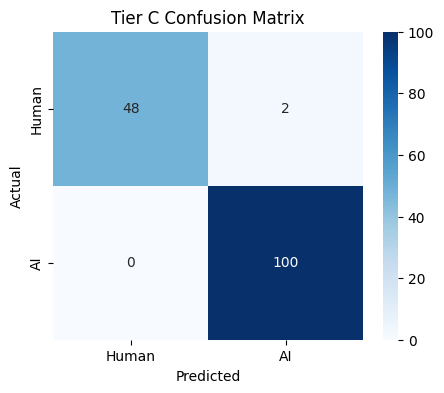

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tier C Confusion Matrix")
plt.show()

In [34]:
trainer.save_model("tier_c_model")
tokenizer.save_pretrained("tier_c_model")

('tier_c_model/tokenizer_config.json', 'tier_c_model/tokenizer.json')

In [35]:
from google.colab import files
import shutil

shutil.make_archive("tier_c_model", "zip", "tier_c_model")
files.download("tier_c_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>